In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np
np.random.seed(20)

**Q1: Stochastic Block Model**

In [2]:
def generate_data(n,q,n_a,p_ab):
    # node vector
    qs = np.zeros(n)
    
    # ad. matrix 
    A = np.zeros([n,n])
    
    # sample from prior
    for i in range(n):
        qs[i] = np.random.choice([0,1],p=n_a)
    qs = qs.astype(int)
    
    # sample from p_ab
    for i in range(n):
        for j in range(n):
            A[i,j] = np.random.choice([0,1],p=[1-p_ab[qs[i],qs[j]],p_ab[qs[i],qs[j]]])
    # zero-out diagonal elements
    for i in range(n):
        A[i,i] = 0    
    return qs, A

**Q2: Posterior**

Group assignments are i.i.d. across nodes, giving the factorized distribution
$$
P(\{g_i\}|\theta) = \prod_{i} \sum_{a} n_a \delta_{g_i,a} = \prod_{i} n_{g_i}
$$
and edges are also independent given the group assignment; using that $A_{ij}\in \{0,1\}$ we can write directly
$$
P(G|\{g_i\},\theta) = \prod_{i\neq j} (p_{g_i,g_j})^{A_{ij}} (1 - p_{g_i,g_j})^{1-A_{ij}},
$$
so we know the joint distribution $P(G,\{g_i\}|\theta) = P(G|\{g_i\},\theta) P(\{g_i\}|\theta)$.
Using Bayes theorem again to access the inverse conditional,
$$
P(\{g_i\}|G,\theta) = \frac{P(G,\{g_i\}|\theta)}{P(G|\theta)} = \frac{P(G,\{g_i\}|\theta)}{\sum_{\{g_i\}} P(G,\{g_i\}|\theta)},
$$
where we exploited furthermore that $P(G|\theta)$ is the marginalization of the joint probability over all group assignments.
Therefore,
$$
H(\{g_i\}|G,\theta) = - \log P(G,\{g_i\}|\theta) = - \sum_{i} \log n_{g_i} -  \sum_{i\neq j} \left[ A_{ij} \log p_{g_i,g_j} +  (1-A_{ij}) \log (1 - p_{g_i,g_j}) \right]
$$
and we directly obtained the form of eq.(3) upon taking the logarithm.

Note: One can also start from writing $P(G|\{g_i\},\theta) = \prod_{i\neq j}^{N} \left[ (p_{g_i,g_j}) \delta(A_{ij}) +  (1 - p_{g_i,g_j}) \delta(A_{ij}-1) \right]$ with delta distributions $\delta(A_{ij})$ and $\delta(A_{ij}-1)$, in which case one can use the two cases $A_{ij}\in \{0,1\}$ to simplify the logarithm of the sum, arriving at the same form of $H(\{g_i\}|G,\theta)$.

**Q3: Define Hamiltonian of Boltzmann measure**

In [3]:
#efficient energy calculation
def energy(q, n_a, p_ab, A):
    N = len(q)
    first_term = np.sum(np.log(np.take(n_a,q)))
    x = np.arange(N)
    pairs_i, pairs_j = np.meshgrid(x, x)
    mask = pairs_i != pairs_j
    pairs_i = pairs_i[mask]
    pairs_j = pairs_j[mask]
    second_term = np.sum(A[pairs_i, pairs_j] * np.log(p_ab[q[pairs_i], q[pairs_j]]) +
                        (1 - A[pairs_i, pairs_j]) * np.log(1 - p_ab[q[pairs_i], q[pairs_j]]))
    return -first_term - second_term

#standard energy calculation
def energy_(q, n_a, p_ab, A):
    N = len(q)
    first_term = np.sum(np.log(np.take(n_a,q)))
    second_term=0
    for i in range(N):
        for j in range(N):
            if i!=j:
                second_term += np.sum(A[i, j] * np.log(p_ab[q[i], q[j]]) +(1 - A[i, j]) * np.log(1 - p_ab[q[i], q[j]]))
    return -first_term - second_term


def energy_difference(q,q_,n_a,p_ab,A):
    return energy(q, n_a, p_ab, A)-energy(q_, n_a, p_ab, A)

**Q4: mcmc**

Generate data

In [4]:
# number of nodes
n = 100
# number of groups
q = 2
# marginal probability of each group 
n_a = [0.7,0.3]
# probability of an edge between a and b
p_ab = np.array([[0.4, 0.1], [0.1, 0.5]])

qs,A = generate_data(n,q,n_a,p_ab)

MCMC

In [5]:
def run_mcmc(T, q0, n_a, p_ab, A):
    q_ = np.copy(q0)  # Current state
    state_history = [np.copy(q0)]  # Make a copy of q0
    
    for t in tqdm(range(T)):
        q_new = np.copy(q_)
        i = np.random.randint(low=0, high=len(q0))
        q_new[i] = int((not q_[i]))
        delta_H = energy_difference(q_new, q_, n_a, p_ab, A)
        prob_accept = min([1, np.exp(-1 * delta_H)])

        if np.random.rand() < prob_accept:
            q_[i] = int(not q_[i])  
        else:
            pass
        state_history.append(np.copy(q_))  
    
    return state_history


**Q5: plot**

In [6]:
T = 5000
q0 = np.random.choice([0,1],size=n)
state_history = run_mcmc(T,q0,n_a,p_ab,A)

100%|██████████| 5000/5000 [00:02<00:00, 2200.79it/s]


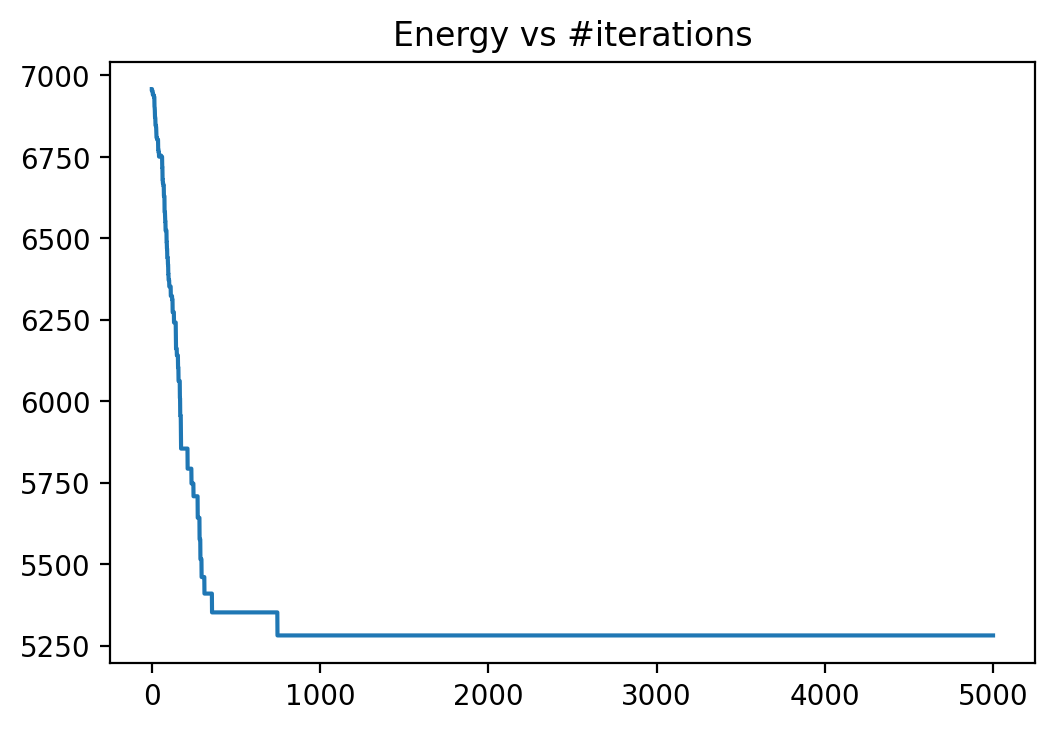

In [7]:
energies = [energy(s, n_a, p_ab, A) for s in state_history]
plt.title('Energy vs #iterations')
plt.plot(energies)

Number of non-zeros in ground-truth 0.3
Average number of non-zeros from last posterior samples 0.29999999999999993


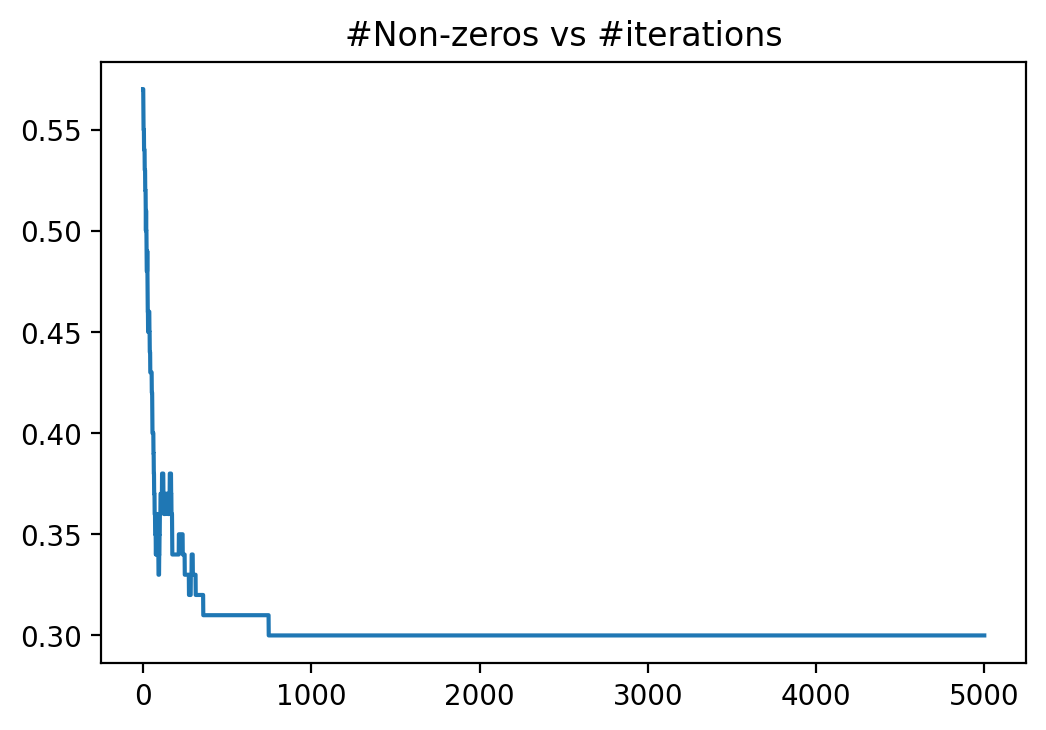

In [8]:
nonzeros = [np.sum(qq==1)/n for qq in state_history]
print('Number of non-zeros in ground-truth',np.sum(qs==1)/n)
print('Average number of non-zeros from last posterior samples', np.mean(nonzeros[-200:]))
plt.title('#Non-zeros vs #iterations')
plt.plot(nonzeros)

Mean of the overlaps
1.0
-0.42857142857142877



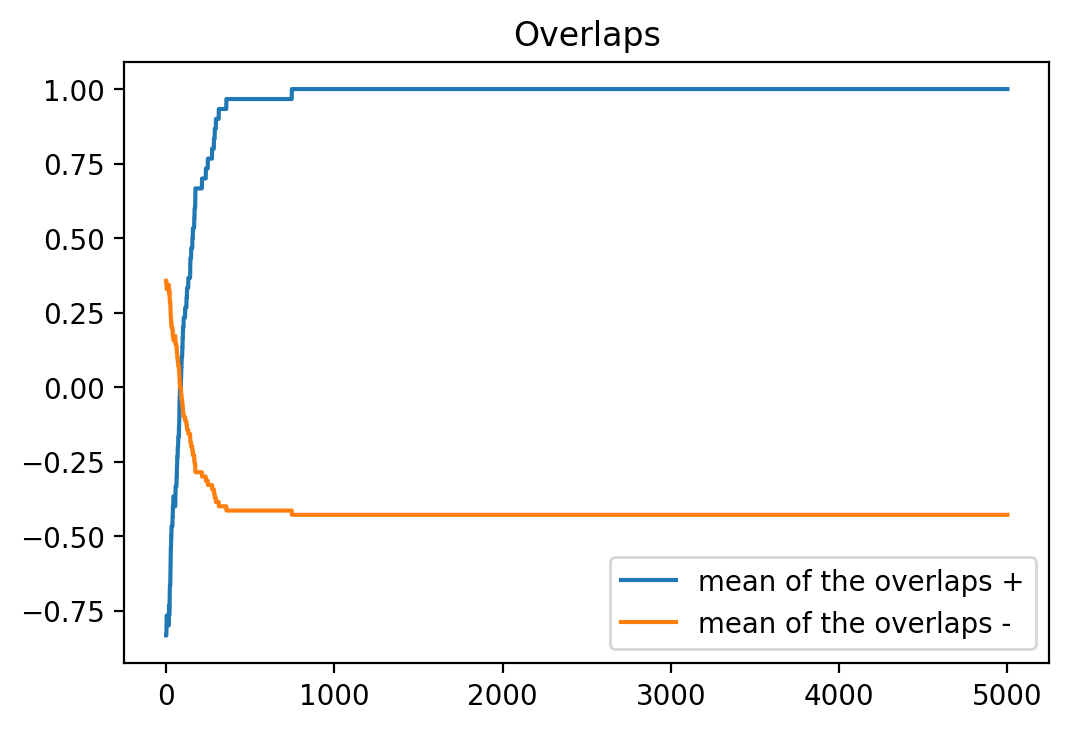

In [9]:
overlap_plus = [(np.mean(qs==qi) - np.max(n_a))/(1-np.max(n_a)) for qi in state_history]
overlap_minus = [(np.mean(qs==(qi==0).astype(int)) - np.min(n_a))/(1-np.min(n_a)) for qi in state_history]
print('Mean of the overlaps')
print(np.mean(overlap_plus[-200:]))
print(np.mean(overlap_minus[-200:]))
print()

plt.figure()
plt.title('Overlaps')
plt.plot(overlap_plus, label='mean of the overlaps +')
plt.plot(overlap_minus, label='mean of the overlaps -')
plt.legend()

**Q6: EM**

EM iteration # 0


100%|██████████| 1200/1200 [00:00<00:00, 2232.81it/s]


EM iteration # 1


100%|██████████| 1200/1200 [00:00<00:00, 2193.85it/s]


EM iteration # 2


...

100%|██████████| 1200/1200 [00:00<00:00, 2171.86it/s]


EM iteration # 6


100%|██████████| 1200/1200 [00:00<00:00, 2187.14it/s]


EM iteration # 7


100%|██████████| 1200/1200 [00:00<00:00, 2024.95it/s]


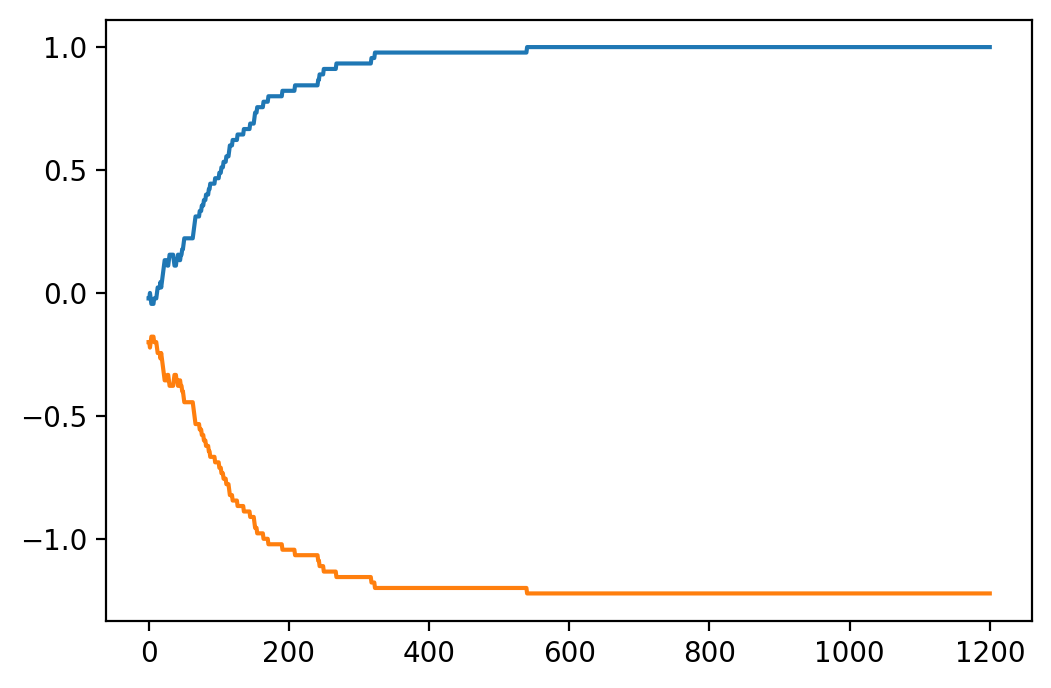

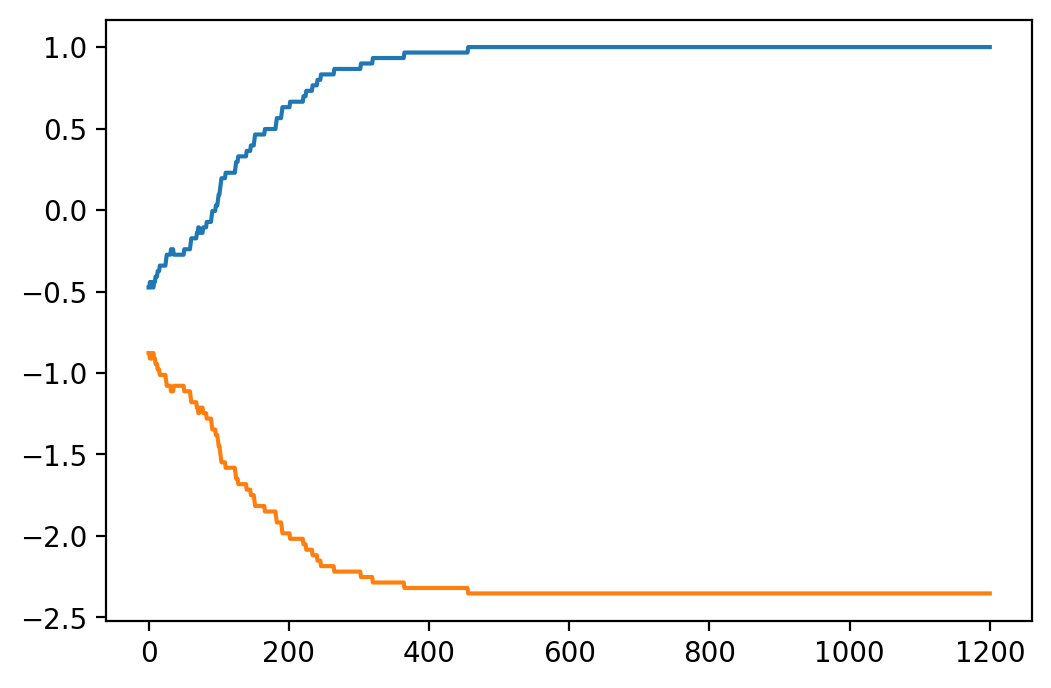

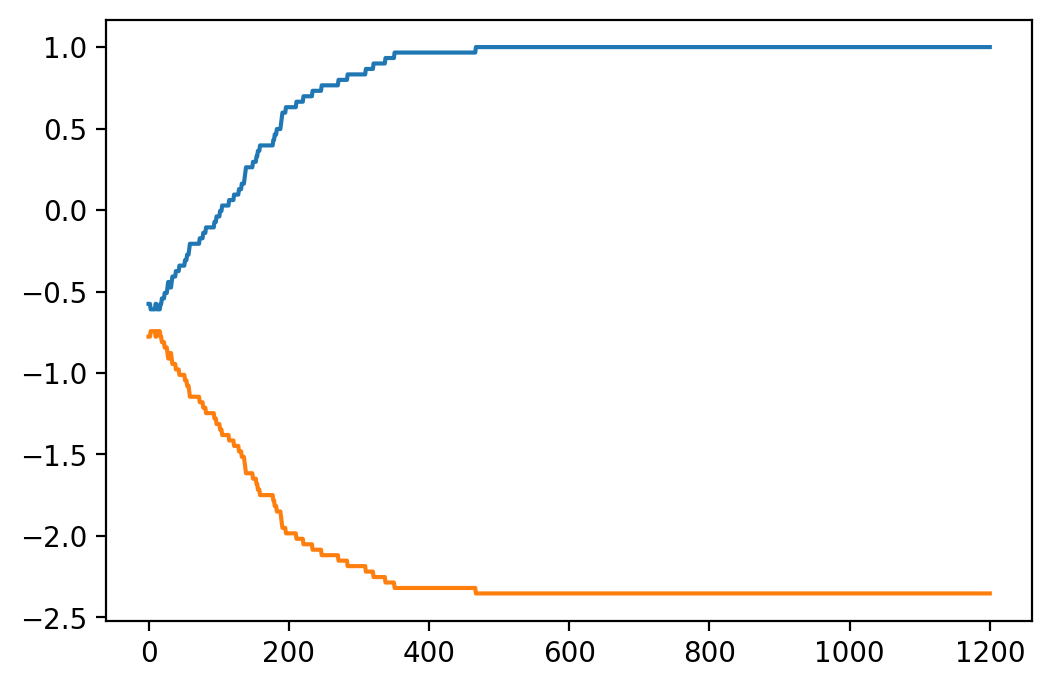

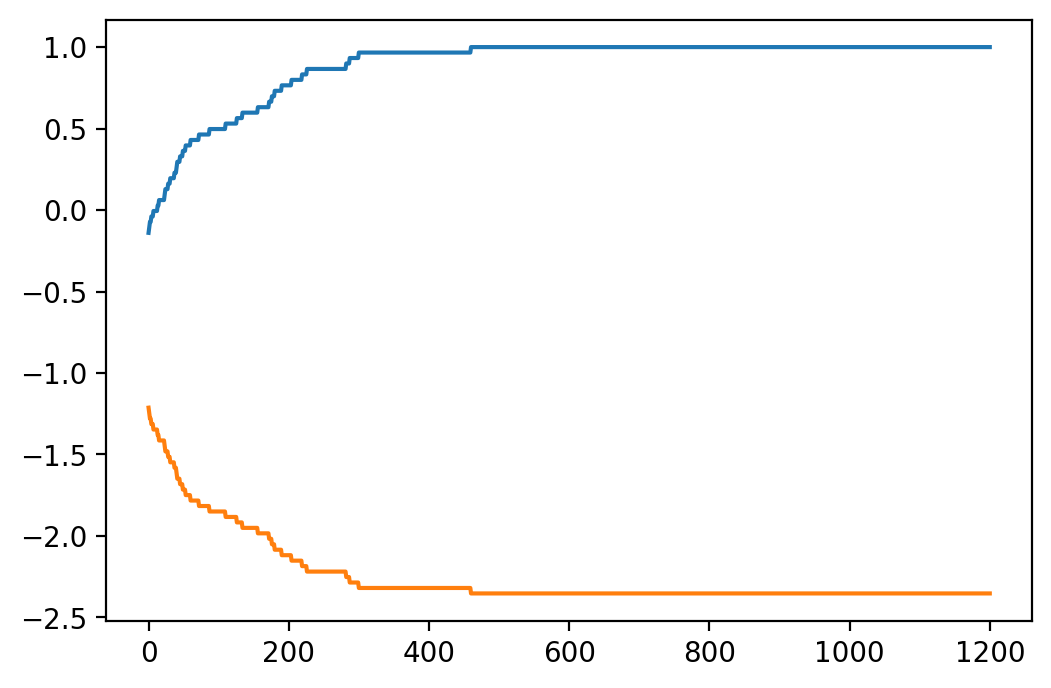

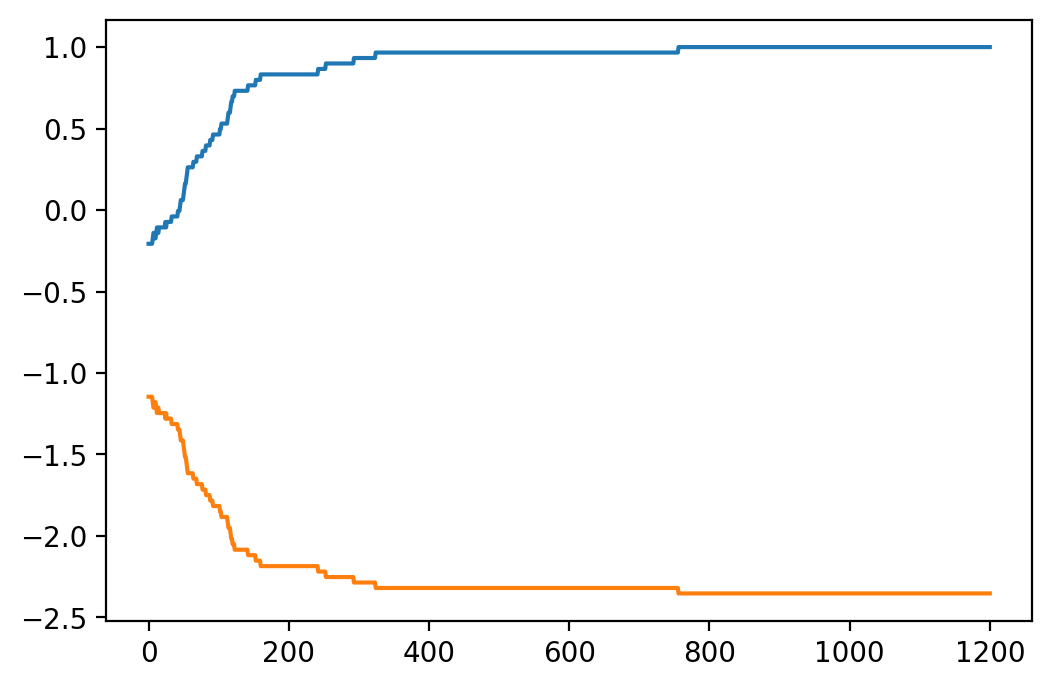

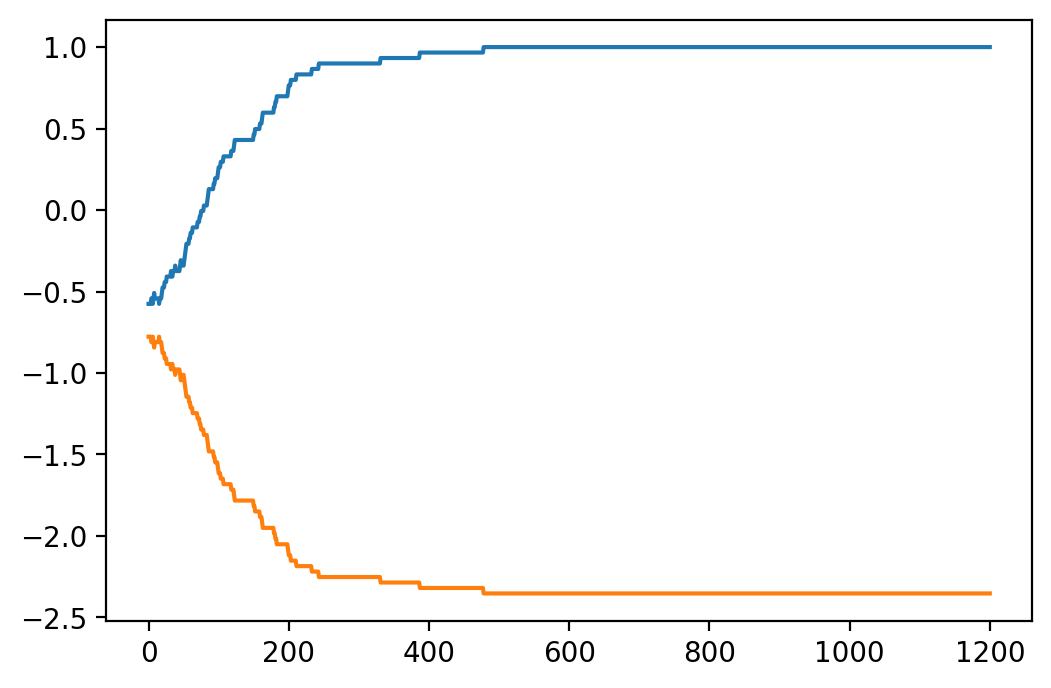

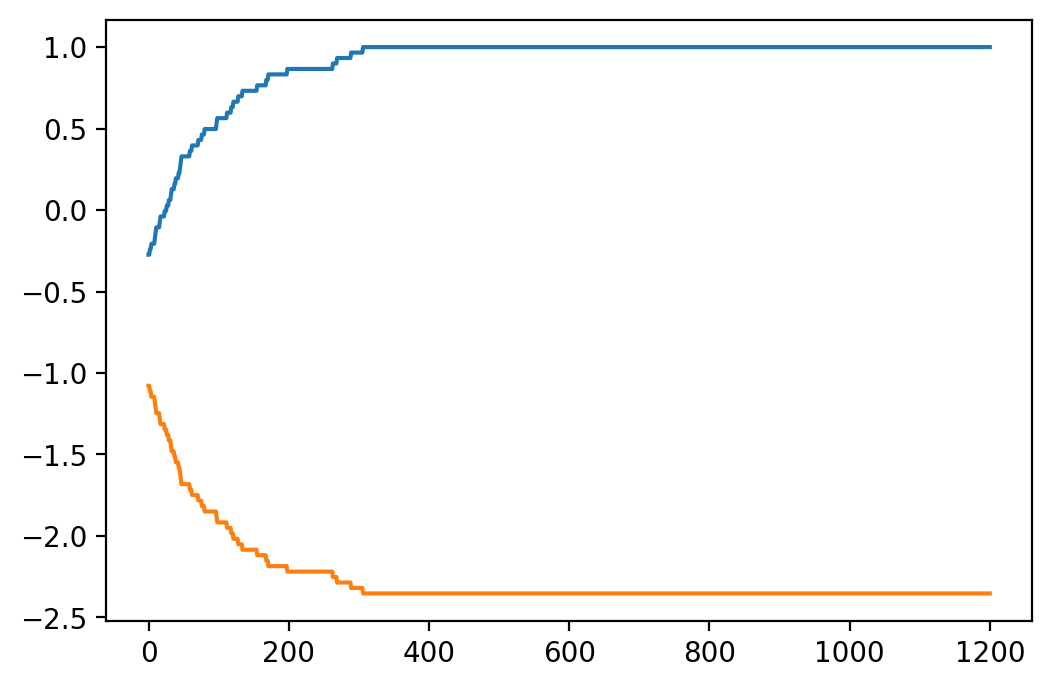

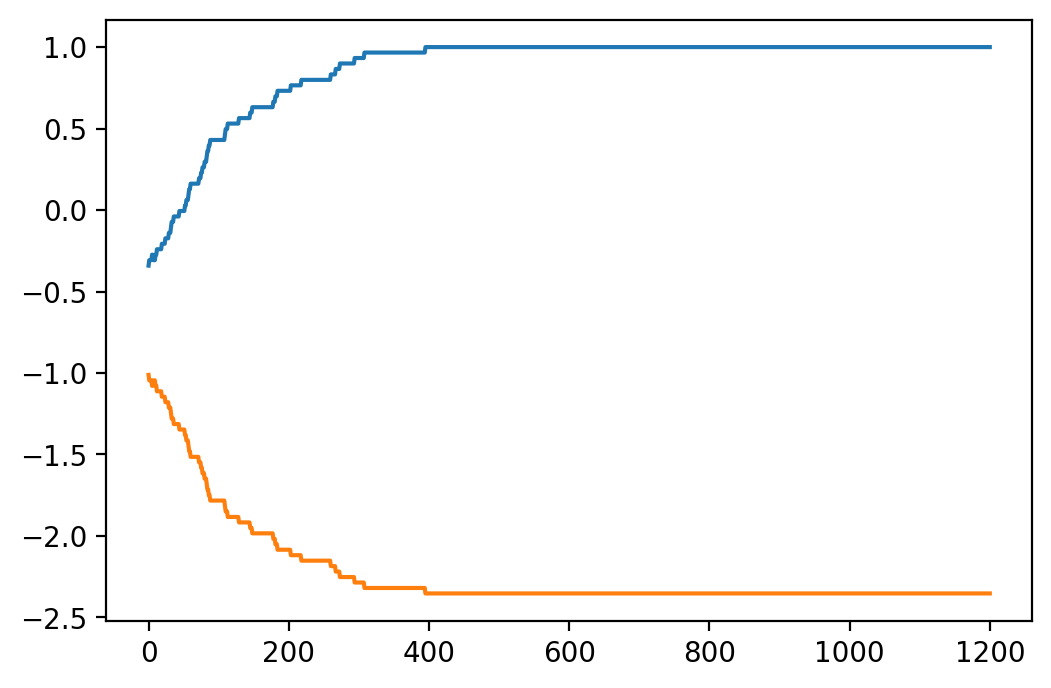

In [10]:
T=1200
T_therm=800
U=8
na=0.55
n_a_history=[na] 

for u in range(U):
    print('EM iteration #', u)
    q=np.random.choice([0,1],p=[na,1-na],size=n)
    state_history=run_mcmc(T,q,[na,1-na],p_ab,A)   
    overlap_plus = [(np.mean(qs==qi) - np.max([na,1-na]))/(1-np.max([na,1-na])) for qi in state_history]
    overlap_minus = [(np.mean(qs==(qi==0).astype(int)) - np.max([na,1-na]))/(1-np.max([na,1-na])) for qi in state_history]
    ps = np.sum(np.array([np.mean(qi==0) for qi in state_history])[T_therm:])     
    na=ps/(T-T_therm)
    n_a_history.append(na)
    plt.figure()
    plt.plot(overlap_plus)
    plt.plot(overlap_minus)

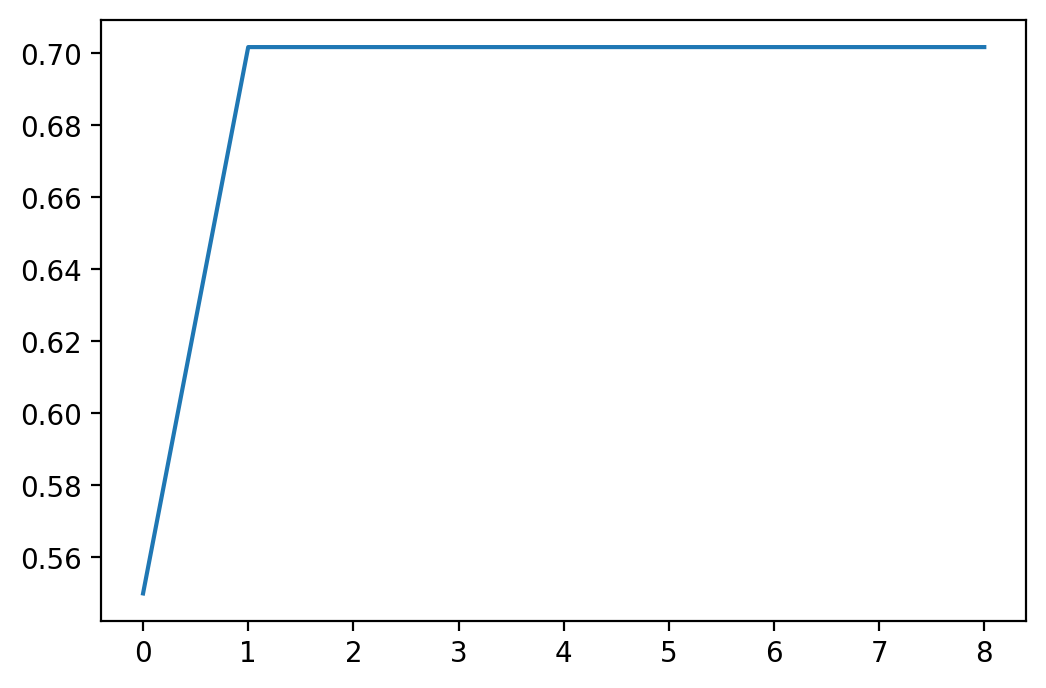

In [11]:
plt.plot(n_a_history)